In [2]:
# 📊 EDA v2 — Walmart Retail Sales Analysis
### **Upgrade from internship:** SQLite → PostgreSQL | Static charts → Plotly interactive | Basic EDA → Deep feature engineering

### What this notebook does:
1. Loads Walmart Sales data into a **PostgreSQL** database
2. Runs **SQL business queries** via SQLAlchemy
3. Builds **interactive Plotly charts** (hover, zoom, filter)
4. Applies **feature engineering** (lag features, rolling averages, holiday dummies)
5. Exports a clean master dataset for EDA v3 (ML forecasting)

In [3]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

print('All libraries loaded successfully')

All libraries loaded successfully


In [4]:
DB_USER     = 'postgres'       # ← change if your username differs
DB_PASSWORD = quote_plus('Sasi@09')  # ← change to your PostgreSQL password
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'walmart_eda'

CONNECTION_STRING = f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'

# Create the engine (this does NOT connect yet — it just stores the config)
engine = create_engine(CONNECTION_STRING)

# Test the connection
try:
    with engine.connect() as conn:
        conn.execute(text('SELECT 1'))
    print('✅ Connected to PostgreSQL successfully!')
    print(f'   Database: {DB_NAME} on {DB_HOST}:{DB_PORT}')
except Exception as e:
    print(f'❌ Connection failed: {e}')
    print('   Check your credentials or make sure PostgreSQL is running')

✅ Connected to PostgreSQL successfully!
   Database: walmart_eda on localhost:5432


In [5]:
df_raw = pd.read_csv("C:/Users/User/OneDrive/Desktop/Internships/DA Intern @ ApexPlanet/Task-2\Walmart_Sales.csv")

print('📋 Raw Dataset Info:')
print(f'   Rows: {df_raw.shape[0]:,}')
print(f'   Columns: {df_raw.shape[1]}')
print(f'   Columns: {list(df_raw.columns)}')
print()
df_raw.head()

📋 Raw Dataset Info:
   Rows: 6,435
   Columns: 8
   Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']



,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,12-02-2010,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,19-02-2010,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,26-02-2010,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,05-03-2010,"1,554,806.68",0,46.50,2.62,211.35,8.11


In [6]:
df_raw['Date'] = pd.to_datetime(df_raw['Date'], dayfirst=True)

numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

for col in numeric_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw['Holiday_Flag'] = df_raw['Holiday_Flag'].astype(int)

df_raw['Store'] = df_raw['Store'].astype(int)

print('Data types fixed:')
print(df_raw.dtypes)
print(f'\nDate range: {df_raw.Date.min().date()} → {df_raw.Date.max().date()}')
print(f'Stores: {df_raw.Store.nunique()} unique stores')
print(f'Missing values:\n{df_raw.isnull().sum()}')

Data types fixed:
Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

Date range: 2010-02-05 → 2012-10-26
Stores: 45 unique stores
Missing values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [7]:
df_raw.to_sql(
    name='walmart_sales',    
    con=engine,
    if_exists='replace',
    index=False,
    method='multi'           
)

print(f'✅ Data loaded into PostgreSQL table: walmart_sales')
print(f'   {len(df_raw):,} rows inserted')

✅ Data loaded into PostgreSQL table: walmart_sales
   6,435 rows inserted


### SQL Business Queries via PostgreSQL

In [8]:
def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query against our PostgreSQL DB and return a DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print('run_query() helper ready')

run_query() helper ready


In [9]:
# ── Q1: Total revenue by store (ranked) ──────────────────────────────────────
q1 = run_query("""
    SELECT
    "Store",
    ROUND(SUM("Weekly_Sales")::NUMERIC, 2) AS total_sales,
    ROUND(AVG("Weekly_Sales")::NUMERIC, 2) AS avg_weekly_sales,
    COUNT(*) AS weeks_recorded,
    RANK() OVER (ORDER BY SUM("Weekly_Sales") DESC) AS sales_rank
FROM walmart_sales
GROUP BY "Store"
ORDER BY total_sales DESC;
""")

print('Total Sales by Store:')
q1.head(10)

Total Sales by Store:


,Store,total_sales,avg_weekly_sales,weeks_recorded,sales_rank
0,20,"301,397,792.46","2,107,676.87",143,1
1,4,"299,543,953.38","2,094,712.96",143,2
2,14,"288,999,911.34","2,020,978.40",143,3
3,13,"286,517,703.80","2,003,620.31",143,4
4,2,"275,382,440.98","1,925,751.34",143,5
5,10,"271,617,713.89","1,899,424.57",143,6
6,27,"253,855,916.88","1,775,216.20",143,7
7,6,"223,756,130.64","1,564,728.19",143,8
8,1,"222,402,808.85","1,555,264.40",143,9
9,39,"207,445,542.47","1,450,668.13",143,10


In [10]:
q2 = run_query("""
    SELECT
        DATE_TRUNC('month', "Date")                    AS month,
        ROUND(SUM("Weekly_Sales")::NUMERIC, 2)         AS monthly_sales,
        ROUND(AVG("Weekly_Sales")::NUMERIC, 2)         AS avg_weekly_sales,
        SUM("Holiday_Flag")                            AS holiday_weeks
    FROM walmart_sales
    GROUP BY DATE_TRUNC('month', "Date")
    ORDER BY month
""")

q2['month'] = pd.to_datetime(q2['month'])
print('Monthly Sales Trend:')
q2.head()

Monthly Sales Trend:


,month,monthly_sales,avg_weekly_sales,holiday_weeks
0,2010-02-01,"190,332,983.04","1,057,405.46",45.00
1,2010-03-01,"181,919,802.50","1,010,665.57",0.00
2,2010-04-01,"231,412,368.05","1,028,499.41",0.00
3,2010-05-01,"186,710,934.34","1,037,282.97",0.00
4,2010-06-01,"192,246,172.36","1,068,034.29",0.00


In [11]:
q3 = run_query("""
    SELECT
        CASE
            WHEN "Holiday_Flag" = 1 THEN 'Holiday Week'
            ELSE 'Normal Week'
        END AS week_type,
        COUNT(*)                                    AS num_weeks,
        ROUND(AVG("Weekly_Sales")::NUMERIC, 2)      AS avg_sales,
        ROUND(MIN("Weekly_Sales")::NUMERIC, 2)      AS min_sales,
        ROUND(MAX("Weekly_Sales")::NUMERIC, 2)      AS max_sales,
        ROUND(STDDEV("Weekly_Sales")::NUMERIC, 2)   AS std_sales
    FROM walmart_sales
    GROUP BY "Holiday_Flag"
    ORDER BY "Holiday_Flag" DESC
""")

print('Holiday vs Non-Holiday:')
q3.head()

Holiday vs Non-Holiday:


,week_type,num_weeks,avg_sales,min_sales,max_sales,std_sales
0,Holiday Week,450,"1,122,887.89","215,359.21","3,004,702.33","627,684.93"
1,Normal Week,5985,"1,041,256.38","209,986.25","3,818,686.45","558,957.44"


In [12]:
q4 = run_query("""
    SELECT
        "Store",
        "Date",
        ROUND("Weekly_Sales"::NUMERIC, 2)  AS weekly_sales,
        "Holiday_Flag",
        ROUND("Temperature"::NUMERIC, 1)   AS temperature,
        ROUND("Fuel_Price"::NUMERIC, 2)    AS fuel_price
    FROM walmart_sales
    ORDER BY "Weekly_Sales" DESC
    LIMIT 10
""")

print('Top 10 Sales Weeks:')
q4


Top 10 Sales Weeks:


,Store,Date,weekly_sales,Holiday_Flag,temperature,fuel_price
0,14,2010-12-24,"3,818,686.45",0,30.60,3.14
1,20,2010-12-24,"3,766,687.43",0,25.20,3.14
2,10,2010-12-24,"3,749,057.69",0,57.10,3.24
3,4,2011-12-23,"3,676,388.98",0,35.90,3.10
4,13,2010-12-24,"3,595,903.20",0,34.90,2.85
5,13,2011-12-23,"3,556,766.03",0,24.80,3.19
6,20,2011-12-23,"3,555,371.03",0,40.20,3.39
7,4,2010-12-24,"3,526,713.39",0,43.20,2.89
8,10,2011-12-23,"3,487,986.89",0,48.40,3.54
9,2,2010-12-24,"3,436,007.68",0,50.00,2.89


In [13]:
q5 = run_query("""
    SELECT
        "Store",
        ROUND(CORR("Temperature",   "Weekly_Sales")::NUMERIC, 3) AS corr_temp,
        ROUND(CORR("Fuel_Price",    "Weekly_Sales")::NUMERIC, 3) AS corr_fuel,
        ROUND(CORR("CPI",           "Weekly_Sales")::NUMERIC, 3) AS corr_cpi,
        ROUND(CORR("Unemployment",  "Weekly_Sales")::NUMERIC, 3) AS corr_unemployment
    FROM walmart_sales
    GROUP BY "Store"
    ORDER BY "Store"
""")

print('Correlation of external factors with weekly sales per store:')
q5.head(10)

Correlation of external factors with weekly sales per store:


,Store,corr_temp,corr_fuel,corr_cpi,corr_unemployment
0,1,-0.22,0.12,0.23,-0.10
1,2,-0.30,-0.20,-0.06,0.07
2,3,-0.38,0.14,0.32,-0.23
3,4,-0.23,0.21,0.35,-0.34
4,5,-0.18,0.17,0.31,-0.21
5,6,-0.09,-0.10,-0.01,0.04
6,7,0.01,0.11,0.29,-0.17
7,8,-0.31,0.03,0.12,-0.05
8,9,-0.21,0.20,0.29,-0.19
9,10,-0.43,-0.18,-0.12,0.13


In [14]:
q6 = run_query("""
    SELECT
        EXTRACT(YEAR FROM "Date")::INT              AS year,
        ROUND(SUM("Weekly_Sales")::NUMERIC, 2)      AS total_sales,
        ROUND(AVG("Weekly_Sales")::NUMERIC, 2)      AS avg_weekly_sales,
        COUNT(DISTINCT "Store")                     AS active_stores,
        SUM("Holiday_Flag")                         AS holiday_weeks
    FROM walmart_sales
    GROUP BY EXTRACT(YEAR FROM "Date")
    ORDER BY year
""")

print('Yearly Summary:')
q6

Yearly Summary:


,year,total_sales,avg_weekly_sales,active_stores,holiday_weeks
0,2010,"2,288,886,120.41","1,059,669.50",45,180.00
1,2011,"2,448,200,007.35","1,046,239.32",45,180.00
2,2012,"2,000,132,859.35","1,033,660.39",45,90.00


## 📈 Section 4 — Interactive Plotly Visualisations
**Upgrade from internship:** All charts are now interactive — hover for values, zoom, click to filter.

 **Load full dataframe from postgreSQL for plotting**

In [15]:
df = run_query('SELECT * FROM walmart_sales ORDER BY "Store", "Date"')

df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week.astype(int)
df['month_name'] = df['Date'].dt.strftime('%b')
df['week_type'] = df['Holiday_Flag'].map({1: 'Holiday', 0: 'Normal'})

print(f'DataFrame loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head(3)

DataFrame loaded: 6,435 rows, 13 columns


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week,month_name,week_type
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11,2010,2,5,Feb,Normal
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11,2010,2,6,Feb,Holiday
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11,2010,2,7,Feb,Normal


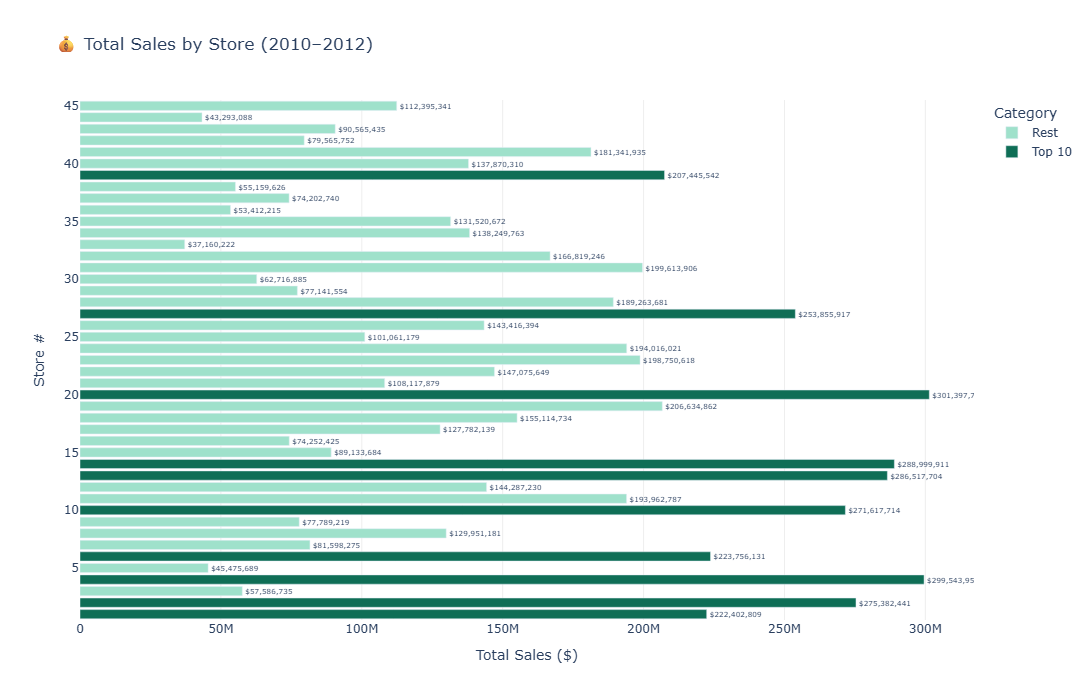

In [16]:
# ── Chart 1: Total Sales by Store (horizontal bar — sorted) ──────────────────
store_sales = df.groupby('Store')['Weekly_Sales'].sum().reset_index()
store_sales.columns = ['Store', 'Total_Sales']
store_sales = store_sales.sort_values('Total_Sales', ascending=True)

store_sales['color'] = store_sales['Total_Sales'].apply(
    lambda x: 'Top 10' if x >= store_sales['Total_Sales'].quantile(0.78) else 'Rest'
)

fig1 = px.bar(
    store_sales,
    x='Total_Sales',
    y='Store',
    orientation='h',
    color='color',
    color_discrete_map={'Top 10': '#0F6E56', 'Rest': '#9FE1CB'},
    title='💰 Total Sales by Store (2010–2012)',
    labels={'Total_Sales': 'Total Sales ($)', 'Store': 'Store #'},
    hover_data={'color': False},
    text='Total_Sales'
)

fig1.update_traces(texttemplate='$%{x:,.0f}', textposition='outside')
fig1.update_layout(
    height=700,
    showlegend=True,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eee'),
    legend_title_text='Category'
)

fig1.show()

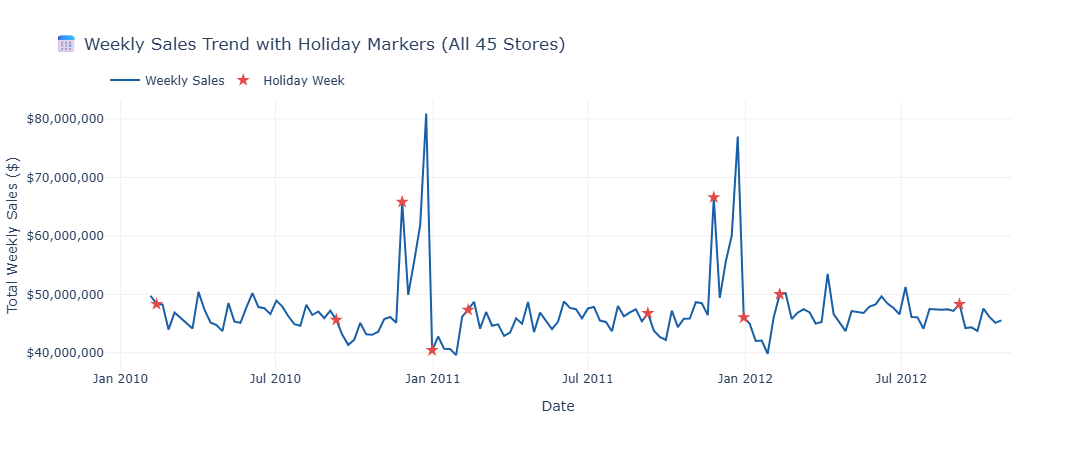

In [17]:
# ── Chart 2: Monthly Sales Trend (line chart with holiday markers) ────────────
monthly = df.groupby('Date').agg(
    total_sales=('Weekly_Sales', 'sum'),
    holiday=('Holiday_Flag', 'max')
).reset_index()

holidays = monthly[monthly['holiday'] == 1]

fig2 = go.Figure()

# Main sales line
fig2.add_trace(go.Scatter(
    x=monthly['Date'],
    y=monthly['total_sales'],
    mode='lines',
    name='Weekly Sales',
    line=dict(color='#185FA5', width=2),
    hovertemplate='Date: %{x|%d %b %Y}<br>Sales: $%{y:,.0f}<extra></extra>'
))

# Holiday markers (red stars)
fig2.add_trace(go.Scatter(
    x=holidays['Date'],
    y=holidays['total_sales'],
    mode='markers',
    name='Holiday Week',
    marker=dict(color='#E24B4A', size=10, symbol='star'),
    hovertemplate='🎉 Holiday Week<br>%{x|%d %b %Y}<br>Sales: $%{y:,.0f}<extra></extra>'
))

fig2.update_layout(
    title='📅 Weekly Sales Trend with Holiday Markers (All 45 Stores)',
    xaxis_title='Date',
    yaxis_title='Total Weekly Sales ($)',
    height=450,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(showgrid=True, gridcolor='#f0f0f0', tickformat='$,.0f'),
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

fig2.show()

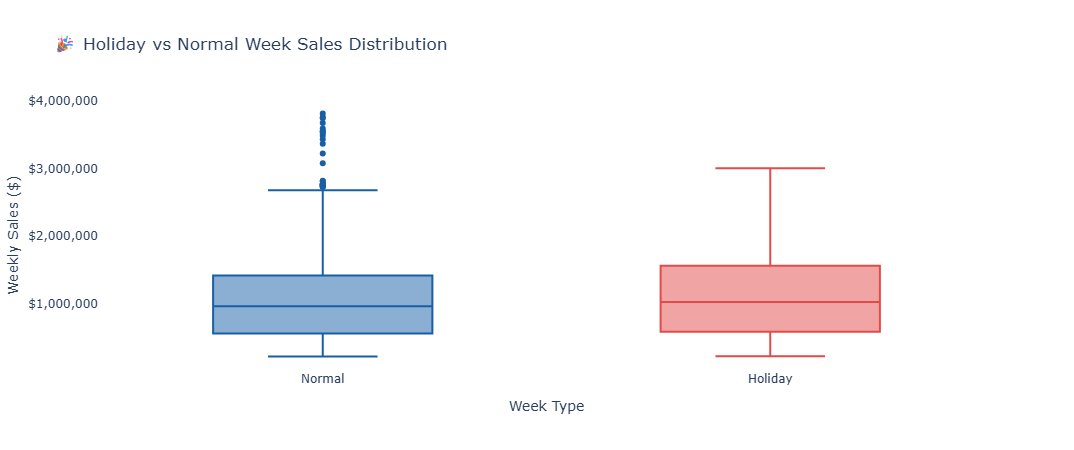

Holiday vs Normal — Summary Stats:


,count,mean,std,min,25%,50%,75%,max
week_type,,,,,,,,
Holiday,450,"1,122,888","627,685","215,359","575,865","1,018,538","1,555,213","3,004,702"
Normal,"5,985","1,041,256","558,957","209,986","551,378","956,211","1,414,344","3,818,686"


In [18]:
# ── Chart 3: Holiday vs Normal Sales Distribution (box plot) ─────────────────
fig3 = px.box(
    df,
    x='week_type',
    y='Weekly_Sales',
    color='week_type',
    color_discrete_map={'Holiday': '#E24B4A', 'Normal': '#185FA5'},
    points='outliers',   # show outlier dots
    title='🎉 Holiday vs Normal Week Sales Distribution',
    labels={'Weekly_Sales': 'Weekly Sales ($)', 'week_type': 'Week Type'}
)

fig3.update_layout(
    height=450,
    plot_bgcolor='white',
    showlegend=False,
    yaxis=dict(tickformat='$,.0f')
)

fig3.show()

# Print summary stats
print('Holiday vs Normal — Summary Stats:')
df.groupby('week_type')['Weekly_Sales'].describe().applymap('{:,.0f}'.format)

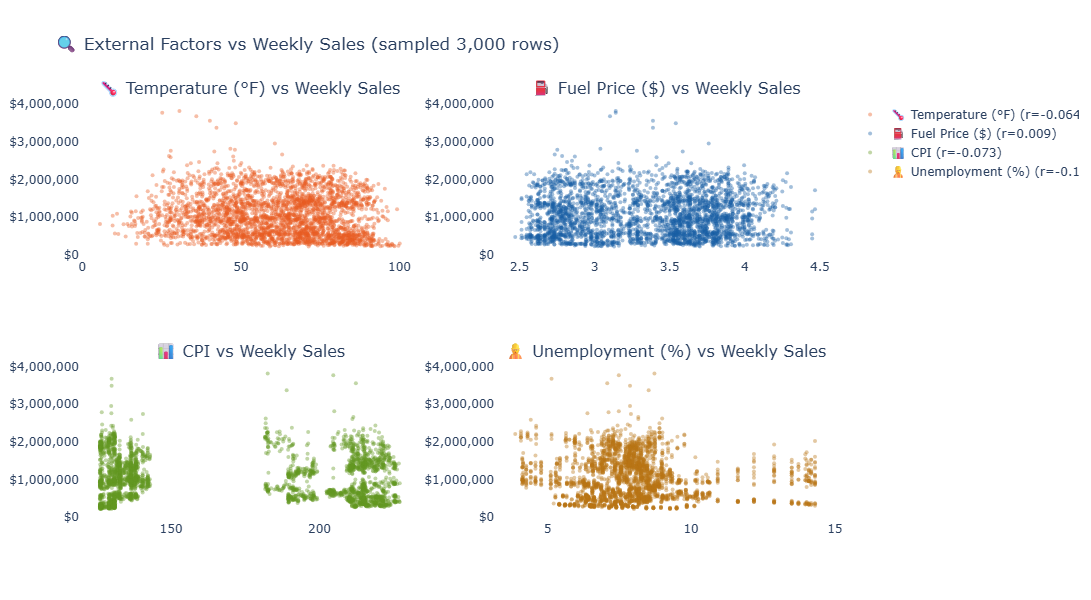

In [19]:
# ── Chart 4: External Factors vs Sales (4-panel scatter) ─────────────────────
factors = [
    ('Temperature',  '🌡️ Temperature (°F)', '#E85D24'),
    ('Fuel_Price',   '⛽ Fuel Price ($)',    '#185FA5'),
    ('CPI',          '📊 CPI',               '#639922'),
    ('Unemployment', '👷 Unemployment (%)',  '#BA7517'),
]

fig4 = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f[1] + ' vs Weekly Sales' for f in factors]
)

sample = df.sample(min(3000, len(df)), random_state=42)

positions = [(1,1), (1,2), (2,1), (2,2)]

for (col, label, color), (r, c) in zip(factors, positions):
    corr_val = df[col].corr(df['Weekly_Sales'])
    fig4.add_trace(
        go.Scatter(
            x=sample[col],
            y=sample['Weekly_Sales'],
            mode='markers',
            marker=dict(color=color, size=4, opacity=0.4),
            name=f'{label} (r={corr_val:.3f})',
            hovertemplate=f'{label}: %{{x}}<br>Sales: $%{{y:,.0f}}<extra></extra>'
        ),
        row=r, col=c
    )

fig4.update_layout(
    title='🔍 External Factors vs Weekly Sales (sampled 3,000 rows)',
    height=600,
    plot_bgcolor='white',
    showlegend=True
)

fig4.update_yaxes(tickformat='$,.0f')

fig4.show()

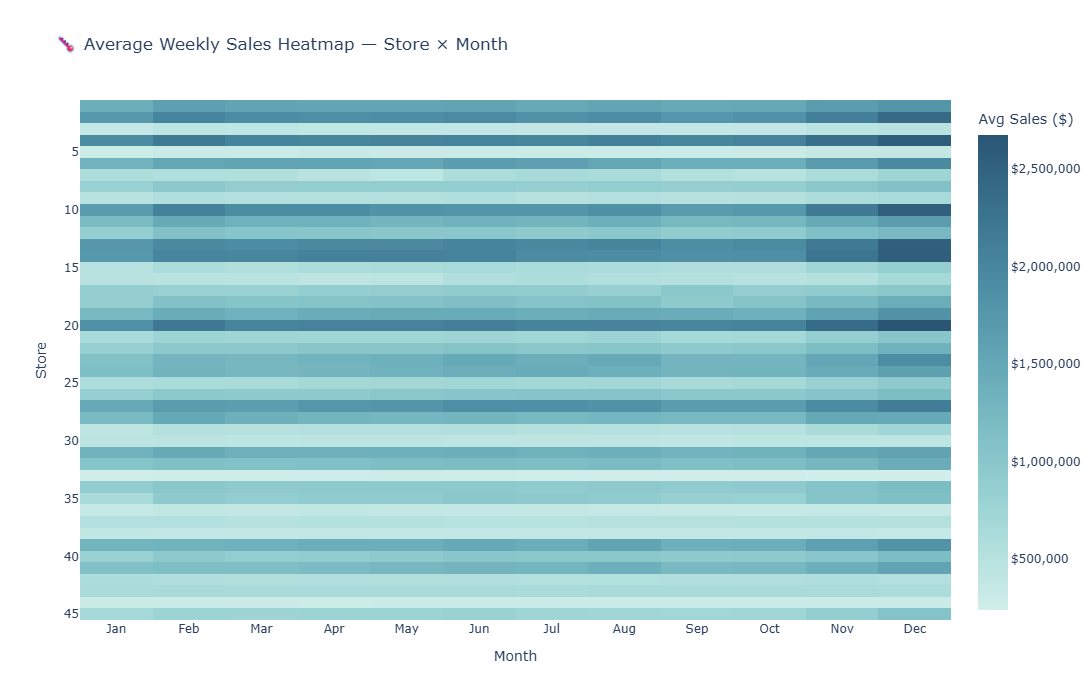

In [20]:
# ── Chart 5: Heatmap — Store × Month average sales ───────────────────────────
pivot = df.groupby(['Store', 'month'])['Weekly_Sales'].mean().reset_index()

pivot_wide = pivot.pivot(
    index='Store',
    columns='month',
    values='Weekly_Sales'
)

pivot_wide.columns = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

fig5 = px.imshow(
    pivot_wide,
    title='🌡️ Average Weekly Sales Heatmap — Store × Month',
    color_continuous_scale='Teal',
    labels=dict(x='Month', y='Store', color='Avg Sales ($)'),
    aspect='auto'
)

fig5.update_layout(
    height=700,
    coloraxis_colorbar=dict(tickformat='$,.0f')
)

fig5.show()

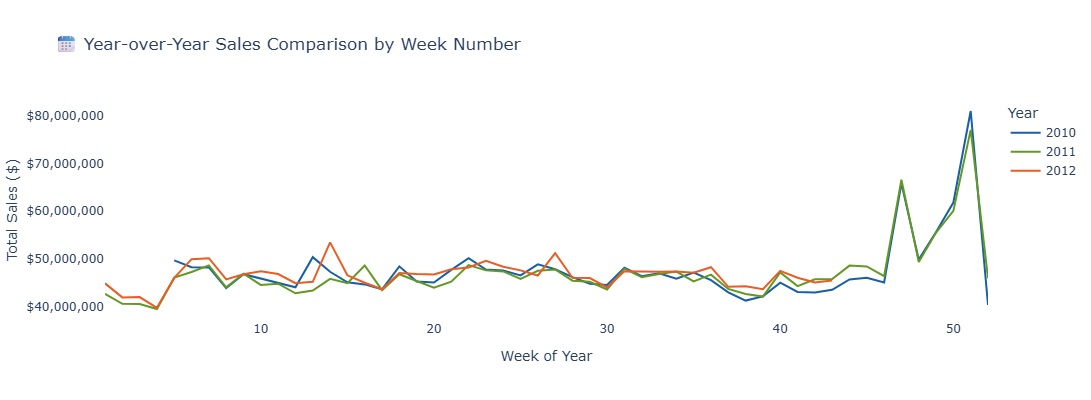

In [21]:
# ── Chart 6: Year-over-Year comparison (line chart) ─────────────────
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)

yoy = df.groupby(['year', 'week_of_year'])['Weekly_Sales'].sum().reset_index()
yoy['year'] = yoy['year'].astype(str)

fig6 = px.line(
    yoy,
    x='week_of_year',
    y='Weekly_Sales',
    color='year',
    color_discrete_map={
        '2010': '#185FA5',
        '2011': '#639922',
        '2012': '#E85D24'
    },
    title='📆 Year-over-Year Sales Comparison by Week Number',
    labels={
        'week_of_year': 'Week of Year',
        'Weekly_Sales': 'Total Sales ($)',
        'year': 'Year'
    }
)

fig6.update_layout(
    height=400,
    plot_bgcolor='white',
    yaxis=dict(tickformat='$,.0f'),
    hovermode='x unified'
)

fig6.show()

## ⚙️ Feature Engineering

This is what separates EDA v2 from the internship version.
We create new columns that will power the ML model in EDA v3.

| Feature | What it captures |
|---|---|
| `lag_1`, `lag_4` | Sales from 1 and 4 weeks ago (momentum) |
| `rolling_4_mean` | 4-week rolling average (trend smoothing) |
| `rolling_4_std` | 4-week rolling std dev (sales volatility) |
| `pct_change_1w` | Week-on-week % change (growth rate) |
| `is_dec`, `is_nov` | High-sales months |
| `pre_holiday` | Week before a holiday |
| `post_holiday` | Week after a holiday |

In [22]:
# ── Feature engineering per store (so lags don't bleed across stores) ─────────
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

def engineer_features(group: pd.DataFrame) -> pd.DataFrame:
    g = group.copy()

    # ── Lag features (past sales) ────────────────────────────────────────────
    g['lag_1']  = g['Weekly_Sales'].shift(1)   # last week
    g['lag_2']  = g['Weekly_Sales'].shift(2)   # 2 weeks ago
    g['lag_4']  = g['Weekly_Sales'].shift(4)   # 1 month ago
    g['lag_52'] = g['Weekly_Sales'].shift(52)  # same week last year

    # ── Rolling statistics (4-week window) ───────────────────────────────────
    g['rolling_4_mean'] = g['Weekly_Sales'].shift(1).rolling(4).mean()
    g['rolling_4_std']  = g['Weekly_Sales'].shift(1).rolling(4).std()
    g['rolling_8_mean'] = g['Weekly_Sales'].shift(1).rolling(8).mean()

    # ── Week-on-week % change ────────────────────────────────────────────────
    g['pct_change_1w'] = g['Weekly_Sales'].pct_change(1) * 100
    g['pct_change_4w'] = g['Weekly_Sales'].pct_change(4) * 100

    # ── Holiday context ──────────────────────────────────────────────────────
    g['pre_holiday']  = g['Holiday_Flag'].shift(-1).fillna(0).astype(int)
    g['post_holiday'] = g['Holiday_Flag'].shift(1).fillna(0).astype(int)

    return g

df_fe = df.groupby('Store', group_keys=False).apply(engineer_features)

# ── Calendar features ─────────────────────────────────────────────────────────
df_fe['is_november'] = (df_fe['month'] == 11).astype(int)
df_fe['is_december'] = (df_fe['month'] == 12).astype(int)
df_fe['is_q4']       = (df_fe['month'].isin([10,11,12])).astype(int)
df_fe['is_summer']   = (df_fe['month'].isin([6,7,8])).astype(int)
df_fe['quarter']     = df_fe['Date'].dt.quarter

# ── Sales tier ────────────────────────────────────────────────────────────────
store_total = df_fe.groupby('Store')['Weekly_Sales'].sum()
quartiles = pd.qcut(store_total, q=4, labels=['Low', 'Medium', 'High', 'Top'])
df_fe['store_tier'] = df_fe['Store'].map(quartiles)

print('Feature engineering complete!')
print(f'   Original columns: {df.shape[1]}')
print(f'   New columns added: {df_fe.shape[1] - df.shape[1]}')
print(f'   Total columns: {df_fe.shape[1]}')
print(f'\nNew features: {[c for c in df_fe.columns if c not in df.columns]}')

Feature engineering complete!
   Original columns: 14
   New columns added: 17
   Total columns: 31

New features: ['lag_1', 'lag_2', 'lag_4', 'lag_52', 'rolling_4_mean', 'rolling_4_std', 'rolling_8_mean', 'pct_change_1w', 'pct_change_4w', 'pre_holiday', 'post_holiday', 'is_november', 'is_december', 'is_q4', 'is_summer', 'quarter', 'store_tier']


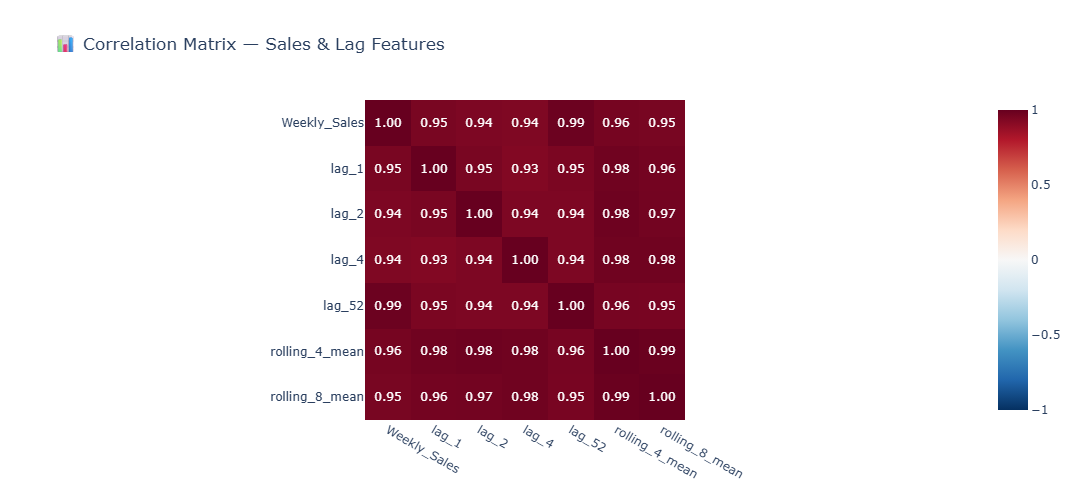


💡 Key insight: lag_1 and rolling_4_mean have strong correlation with
   Weekly_Sales — these will be powerful features for the ML model in v3!


In [23]:
# ── Visualise lag feature correlation ────────────────────────────────────────
lag_cols = [
    'Weekly_Sales',
    'lag_1',
    'lag_2',
    'lag_4',
    'lag_52',
    'rolling_4_mean',
    'rolling_8_mean'
]

corr_matrix = df_fe[lag_cols].corr()

fig_corr = px.imshow(
    corr_matrix,
    title='📊 Correlation Matrix — Sales & Lag Features',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    text_auto='.2f'
)

fig_corr.update_layout(height=500)
fig_corr.show()

print('\n💡 Key insight: lag_1 and rolling_4_mean have strong correlation with')
print('   Weekly_Sales — these will be powerful features for the ML model in v3!')

In [24]:
df_fe.to_sql(
    name='walmart_features',
    con=engine,
    if_exists='replace',
    index=False,
    method='multi'
)

print('Feature table pushed to PostgreSQL: walmart_features')

Feature table pushed to PostgreSQL: walmart_features


In [26]:
output_path = "C:/Users/User/OneDrive/Desktop/Projects/walmart_features.csv"
df_fe.to_csv(output_path, index=False)
print(f'CSV saved: {output_path}')
print(f'   Shape: {df_fe.shape}')
print(f'\n📌 This file is the input for EDA v3 (ML Forecasting notebook)')

CSV saved: C:/Users/User/OneDrive/Desktop/Projects/walmart_features.csv
   Shape: (6435, 31)

📌 This file is the input for EDA v3 (ML Forecasting notebook)
